### Create SMET Forcing Files from Met Station Data (filled with HRRR-AK): Point Simulation Heen Latinee SNOTEL (HEEN)

Notebook contents 
* SNOWPACK takes an SMET file, so let's create that for point simulations

created by Cassie Lumbrazo\
last updated: May 2026\
run location: UAS linux\
python environment: **rasterio**

In [27]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

import rioxarray
import rasterio 
import cfgrib
import os

import geopandas as gpd

from zoneinfo import ZoneInfo
from pathlib import Path

In [28]:
pwd

'/home/cassie/python/repos/snow_modeling_point/sites/heen'

## Load Heen SNOTEL Data: Cleaned in `1_clean_met_heen.ipynb`

In [35]:
# open observations
# file_heen = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/site1270_hourly_2016_2026.nc"
file_heen_clean_cut = "/hdd/snow_hydrology/met_station/snotel/heenlatinee/heen_met_2018_2022_cleaned_v1.nc"
ds_met = xr.open_dataset(file_heen_clean_cut)

# cut the datetime to be from 2024 10 01 to 2025 09 30 to match the snowpack output
ds_met = ds_met.sel(time=slice("2019-10-01T05:00:00", "2022-09-30T05:00:00"))
ds_met


<xarray.Dataset> Size: 2MB
Dimensions:           (time: 23483)
Coordinates:
  * time              (time) datetime64[ns] 188kB 2019-10-01T05:00:00 ... 202...
Data variables:
    swe               (time) float64 188kB ...
    temp              (time) float64 188kB ...
    hs                (time) float64 188kB ...
    rh                (time) float64 188kB ...
    precip_accum      (time) float64 188kB ...
    wind              (time) float64 188kB ...
    wind_dir          (time) float64 188kB ...
    pressure          (time) float64 188kB ...
    precip_rate       (time) float64 188kB ...
    precip_accum_1hr  (time) float64 188kB ...

In [36]:
# print the first few timesteps of the ds 
ds_met.time.values[:10]

array(['2019-10-01T05:00:00.000000000', '2019-10-01T06:00:00.000000000',
       '2019-10-01T07:00:00.000000000', '2019-10-01T08:00:00.000000000',
       '2019-10-01T09:00:00.000000000', '2019-10-01T10:00:00.000000000',
       '2019-10-01T11:00:00.000000000', '2019-10-01T12:00:00.000000000',
       '2019-10-01T13:00:00.000000000', '2019-10-01T14:00:00.000000000'],
      dtype='datetime64[ns]')

In [31]:
# # plot all the variables to see what we have and how they look
# for var in ds_met.data_vars:
#     plt.figure()
#     ds_met[var].plot()
#     plt.title(f"{var} Time Series at HEEN SNOTEL WY2021")
#     plt.xlabel("Time")
#     plt.ylabel(f"{var} ({ds_met[var].attrs.get('units', '')})")
#     plt.grid(True, alpha=0.3)
#     plt.show()
    

We should not need much cleaning here since we did it largely in script 1...

_________________________________________________________________

## Load the HRRR-AK Dataset

In [33]:
# input_file = "/hdd/snow_hydrology/hrrrak/large_juneau_domain/netcdf/hrrrak_f567_WY2025_utm_site_heen.nc"
input_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/netcdf/hrrrak_f567_WY2020-WY2025_utm_site_heen.nc"
ds_hrrr = xr.open_dataset(input_file)
ds_hrrr.rio.write_crs("EPSG:32608", inplace=True) # we know it is in UTM from the previous script work

# and clip to WY2020,2021,2022 
ds_hrrr = ds_hrrr.sel(time=slice("2019-10-01T05:00:00", "2022-09-30T05:00:00"))
ds_hrrr

<xarray.Dataset> Size: 7MB
Dimensions:       (time: 26281)
Coordinates:
    valid_time    (time) datetime64[ns] 210kB ...
    step          (time) timedelta64[ns] 210kB ...
  * time          (time) datetime64[ns] 210kB 2019-10-01T05:00:00 ... 2022-09...
    y             float64 8B ...
    x             float64 8B ...
    spatial_ref   int64 8B 0
Data variables: (12/28)
    gust          (time) float64 210kB ...
    pressure      (time) float64 210kB ...
    orog          (time) float64 210kB ...
    temp_surface  (time) float64 210kB ...
    swe           (time) float64 210kB ...
    snowdepth     (time) float64 210kB ...
    ...            ...
    suswrf        (time) float64 210kB ...
    sulwrf        (time) float64 210kB ...
    wind          (time) float64 210kB ...
    wind_dir      (time) float64 210kB ...
    veg           (time) float64 210kB ...
    lai           (time) float64 210kB ...
Attributes: (12/13)
    long_name:       Wind speed (gust)
    units:           m s**-1
    GRIB_shortName:  gust
    GRIB_name:       Wind speed (gust)
    GRIB_cfName:     unknown
    GRIB_cfVarName:  gust
    ...              ...
    typeOfLevel:     surface
    site_name:       heen
    original_lat:    58.69652
    original_lon:    -134.86448
    utm_x:           507854.334991801
    utm_y:           6506268.082489309

In [34]:
# print the first few timesteps of the ds 
ds_hrrr.time.values[:10]

array(['2019-10-01T05:00:00.000000000', '2019-10-01T06:00:00.000000000',
       '2019-10-01T07:00:00.000000000', '2019-10-01T08:00:00.000000000',
       '2019-10-01T09:00:00.000000000', '2019-10-01T10:00:00.000000000',
       '2019-10-01T11:00:00.000000000', '2019-10-01T12:00:00.000000000',
       '2019-10-01T13:00:00.000000000', '2019-10-01T14:00:00.000000000'],
      dtype='datetime64[ns]')

In [37]:
# check that both datasets have the same time range and frequency
print("HEEN SNOTEL Met Dataset:")
print(f"Start: {ds_met.time.values[0]}, End: {ds_met.time.values[-1]}, Frequency: {pd.infer_freq(ds_met.time.values)}")
print("\nHRRR AK Dataset:")
print(f"Start: {ds_hrrr.time.values[0]}, End: {ds_hrrr.time.values[-1]}, Frequency: {pd.infer_freq(ds_hrrr.time.values)}")

HEEN SNOTEL Met Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: None

HRRR AK Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: h


In [38]:
# Create continuous hourly time axis
ds_met = (ds_met.resample(time='1h').asfreq())

In [39]:
# check that both datasets have the same time range and frequency
print("HEEN SNOTEL Met Dataset:")
print(f"Start: {ds_met.time.values[0]}, End: {ds_met.time.values[-1]}, Frequency: {pd.infer_freq(ds_met.time.values)}")
print("\nHRRR AK Dataset:")
print(f"Start: {ds_hrrr.time.values[0]}, End: {ds_hrrr.time.values[-1]}, Frequency: {pd.infer_freq(ds_hrrr.time.values)}")

HEEN SNOTEL Met Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: h

HRRR AK Dataset:
Start: 2019-10-01T05:00:00.000000000, End: 2022-09-30T05:00:00.000000000, Frequency: h


Compare Precipiation, 

In [40]:
ds_hrrr['precip_accum_1hr'] = ds_hrrr['precip_rate'] * 3600 # convert from mm/s to mm/hr for comparison with the observed data

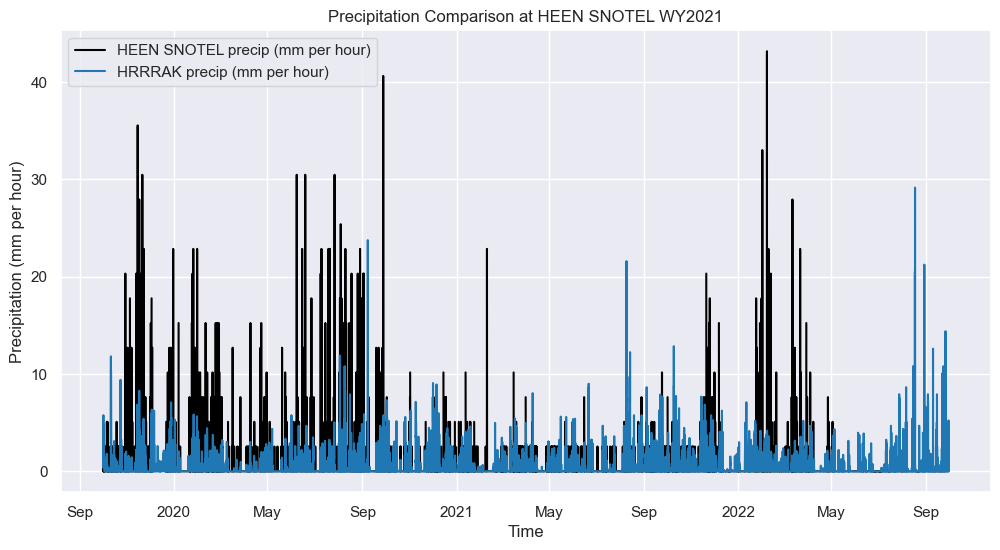

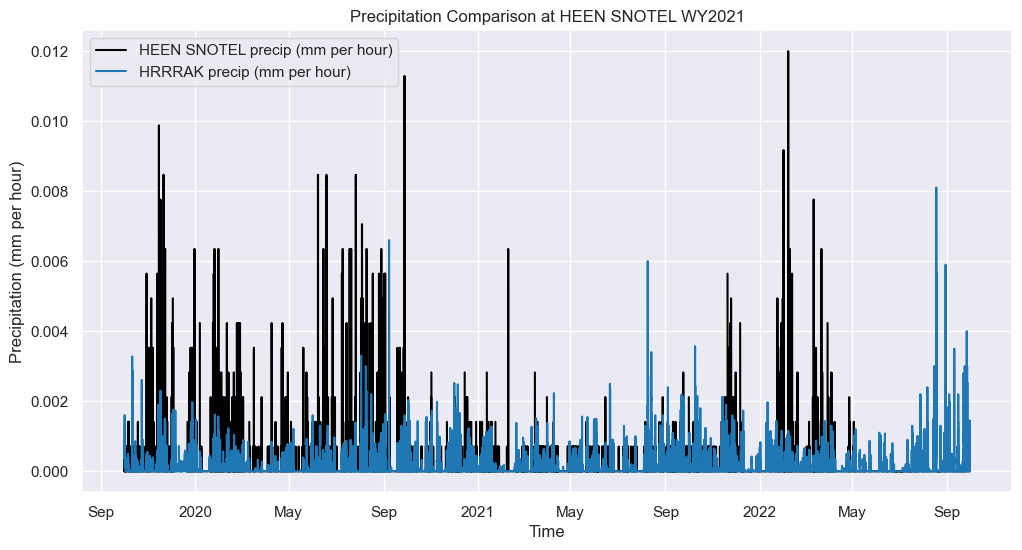

In [41]:
# compare precip 
ds_met["precip_accum_1hr"].plot(label="HEEN SNOTEL precip (mm per hour)", color='black')
ds_hrrr['precip_accum_1hr'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
plt.title("Precipitation Comparison at HEEN SNOTEL WY2021")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm per hour)")
plt.legend()
plt.show()

# compare precip 
ds_met["precip_rate"].plot(label="HEEN SNOTEL precip (mm per hour)", color='black')
ds_hrrr['precip_rate'].plot(label="HRRRAK precip (mm per hour)", color='tab:blue')
plt.title("Precipitation Comparison at HEEN SNOTEL WY2021")
plt.xlabel("Time")
plt.ylabel("Precipitation (mm per hour)")
plt.legend()
plt.show()

Compare accumulated precip, 

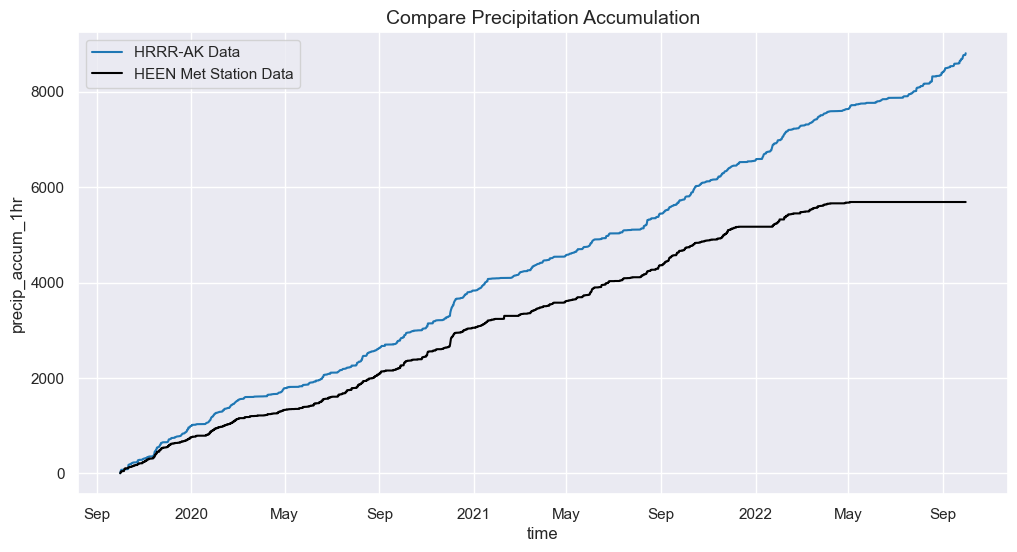

In [42]:
ds_hrrr['precip_accum_1hr'].cumsum().plot(label='HRRR-AK Data', color='tab:blue')

# now divide precip accum by 2 to compare 
# (ds_hrrr['precip_accum_1hr'].cumsum() / 1.3).plot(label='HRRR-AK Data Scale (Divide) by 1.3', color='tab:orange')
ds_met['precip_accum_1hr'].cumsum().plot(label='HEEN Met Station Data', color='black')

plt.title('Compare Precipitation Accumulation', fontsize=14)
plt.legend()
plt.show()

Air temperature, 

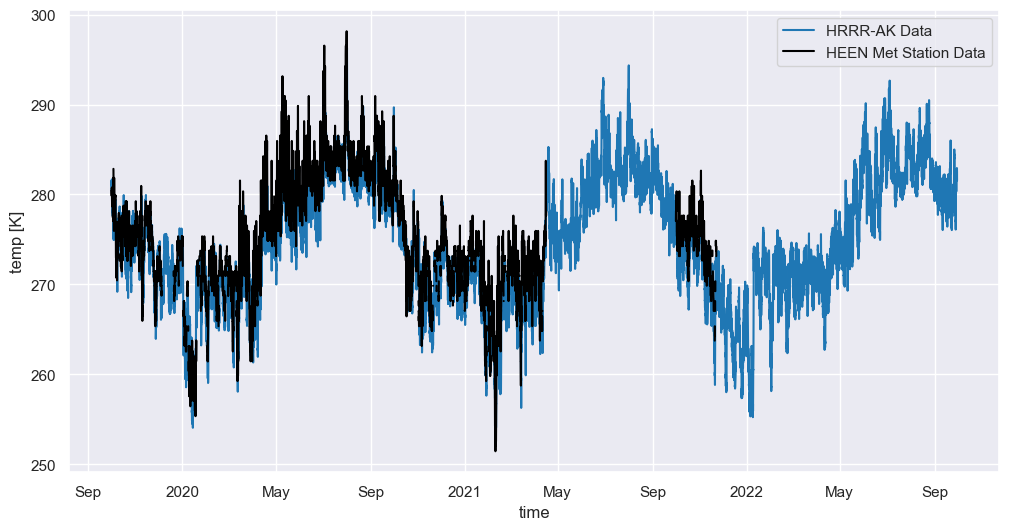

In [43]:
# compare temp
ds_hrrr.temp.plot(label='HRRR-AK Data', color='tab:blue')
ds_met.temp.plot(label='HEEN Met Station Data', color='black')

plt.legend()

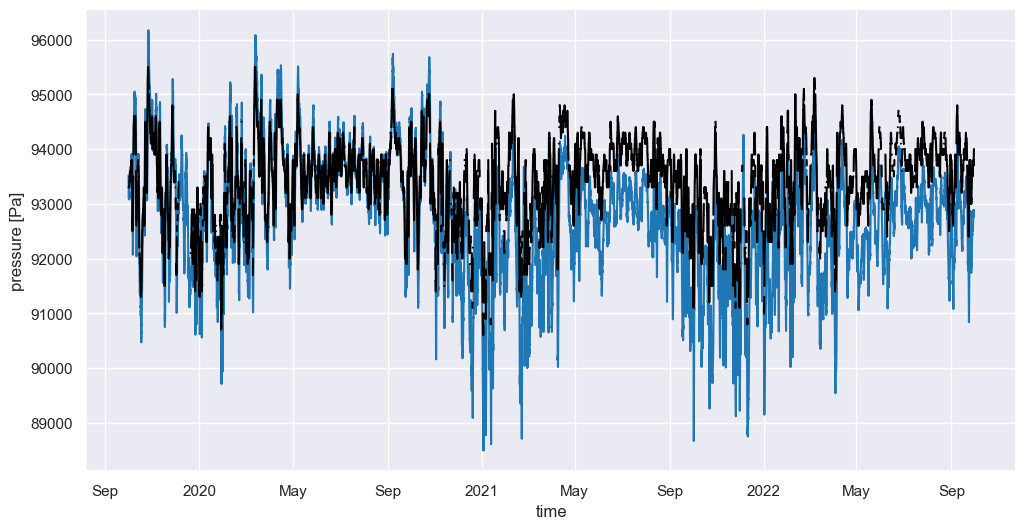

In [44]:
# compare pressure
ds_hrrr['pressure'].plot(label='HRRR-AK Data', color='tab:blue')
ds_met['pressure'].plot(label='HEEN Met Station Data', color='black')

Relative Humidity, 

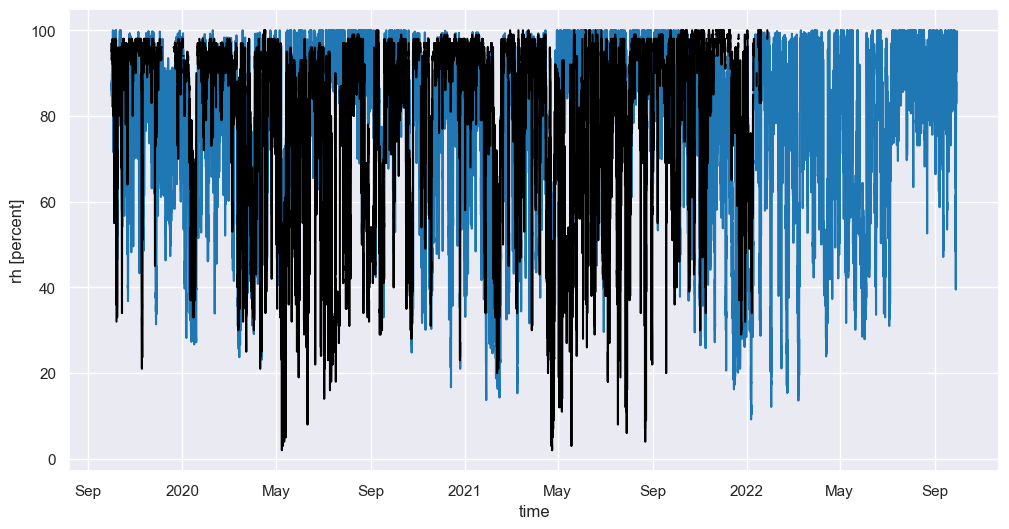

In [45]:
# compare rh 
ds_hrrr['rh'].plot(label='HRRR-AK Data', color='tab:blue')
ds_met['rh'].plot(label='HEEN Met Station Data', color='black')

Wind speed, 

Text(0, 0.5, 'Wind Speed (m/s)')

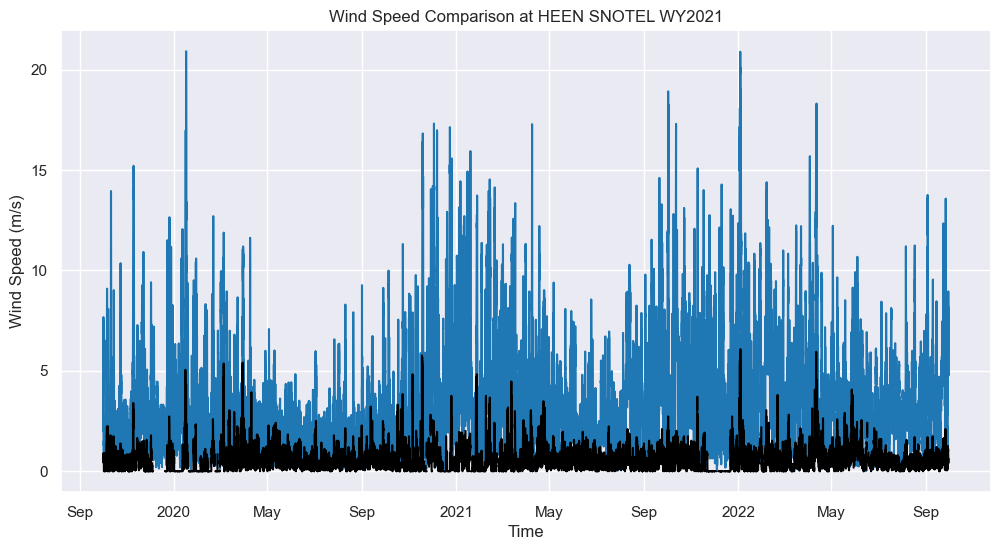

In [46]:
# compare wind speed 
ds_hrrr['wind'].plot(label="HRRRAK wind speed (m/s)", color='tab:blue')
ds_met['wind'].plot(label="HEEN SNOTEL wind speed (m/s)", color='black') # this should be converted to m/s
plt.title("Wind Speed Comparison at HEEN SNOTEL WY2021")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")

We are not going to use wind speed or direction from this station since we know the sesnor is a RMYoung5103 and it gets rimed up very easily. The wind speeds seem exceptonally low for this site, so we will use HRRR.

Wind direction, 

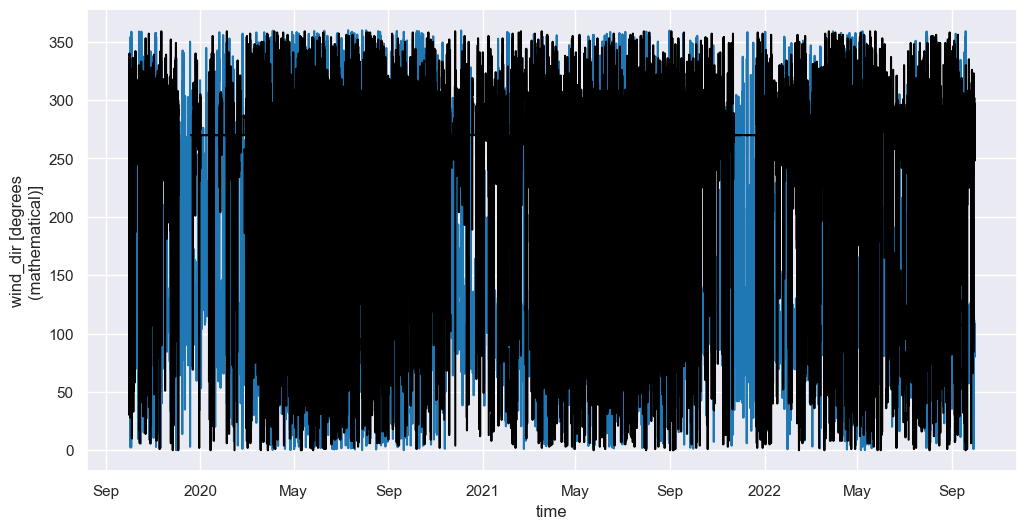

In [47]:
# comapre wind direction 
ds_hrrr['wind_dir'].plot(label="HRRRAK wind direction (degrees)", color='tab:blue')
ds_met['wind_dir'].plot(label="HEEN SNOTEL wind direction (degrees)", color='black') # this should be converted to degrees meteorological

In [48]:
# print the first few timestamps to see the time resolution
print(ds_hrrr.time.values[:10])

['2019-10-01T05:00:00.000000000' '2019-10-01T06:00:00.000000000'
 '2019-10-01T07:00:00.000000000' '2019-10-01T08:00:00.000000000'
 '2019-10-01T09:00:00.000000000' '2019-10-01T10:00:00.000000000'
 '2019-10-01T11:00:00.000000000' '2019-10-01T12:00:00.000000000'
 '2019-10-01T13:00:00.000000000' '2019-10-01T14:00:00.000000000']


# The Workflow Below, 

HRRR (NetCDF / xarray)\
   → your Python script\
   → SMET (ASCII)\
   → SNOWPACK


#### MeteoIO Variable Names 
| MeteoIO name | Meaning                      | Required?            | Expected units              |
| ------------ | ---------------------------- | -------------------- | --------------------------- |
| `TA`         | Air temperature              | yes                  | °K                          |
| `RH`         | Relative humidity            | yes                  | fraction (0-1)              |
| `VW`         | Wind speed                   | yes                  | m s⁻¹                       |
| `DW`         | Wind direction               | optional             | degrees (0–360, from North) |
| `ISWR`       | Incoming shortwave radiation | strongly recommended | W m⁻²                       |
| `ILWR`       | Incoming longwave radiation  | strongly recommended | W m⁻²                       |
| `PSUM`       | Precipitation (increment)    | yes                  | mm (per timestep)           |
| `P`          | Air pressure                 | optional             | Pa                          |


HRRR to MeteIO Variable Mapping 

In [49]:
# --- Unit expectations (SMET / MeteoIO) ---
# TA    : Kelvin
# RH    : fraction (0–1)
# VW    : m s-1
# DW    : degrees (meteorological)
# ISWR : W m-2
# ILWR : W m-2
# PSUM : mm per timestep
# P     : Pa

# Create SMET File

In [50]:
from pathlib import Path
from pyproj import Transformer

In [19]:
# lat_ppsa2, lon_ppsa2, elevation_ppsa2 = 58.26200, -134.51700, 670
# lat_tram, lon_tram, elevation_tram = 58.2971, -134.386, 529
lat_heen, lon_heen, elevation_heen = 58.69652, -134.86448, 548
# lat_tkg4, lon_tkg4, elevation_tkg4 = 58.63447,-134.23708, 1120

In [20]:
# relate the variables, df_met is for the met station data 
ds_met = ds_met.copy()

# ds is for the HRRRAK data
ds_hrrrak = ds_hrrr.copy()

New Code, 

ds_met time range: 2019-10-01T05:00:00.000000000 to 2022-09-30T05:00:00.000000000
ds_hrrrak time range: 2019-10-01T05:00:00.000000000 to 2022-09-30T05:00:00.000000000
Original met data coverage:
0.24229622689719787
After alignment to HRRR time:
0.24229622689719787
First few aligned precip values:
[2.54 2.54 2.54 0.   2.54 2.54 0.   2.54 0.   2.54]
Fraction of timesteps using met data:
TA: 0.49199041132377
RH: 0.6745938130208136
PSUM: 0.8934972033027663
Mixed precipitation differs from HRRR at:
8522
SMET file written to: /home/cassie/python/models/run_snowpack/sites/heen/input/met_hrrrak_heen_WY2020-WY2022.smet


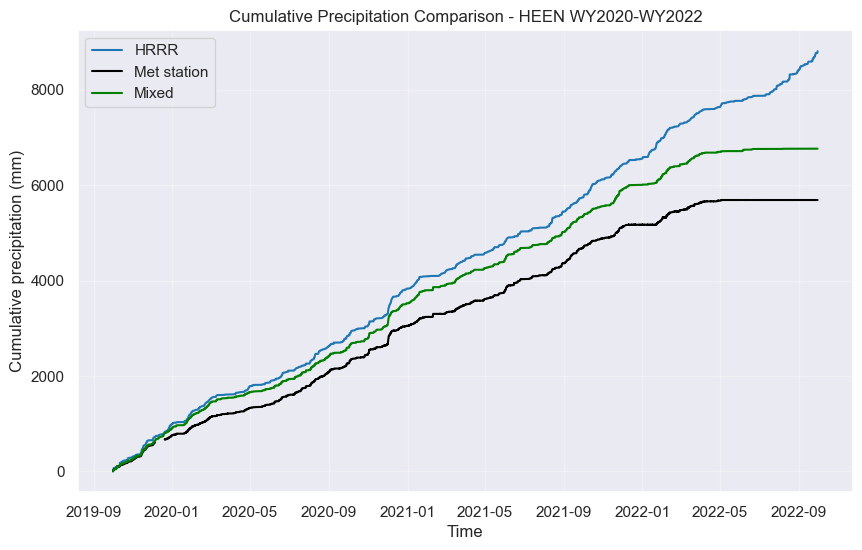

In [51]:
import xarray as xr
import pandas as pd
import numpy as np
from pathlib import Path
from pyproj import Transformer
import matplotlib.pyplot as plt

# =========================
# SLICE DATASETS TO COMMON TIME RANGE (WY2020,WY2021,WY2022)
# =========================

# (time=slice("2019-10-01T05:00:00", "2022-09-30T05:00:00"))

start_time = '2019-10-01T05:00'
end_time = '2022-09-30T05:00'  # WY2020, WY2021, WY2022

# Slice datasets
ds_met = ds_met.sel(time=slice(start_time, end_time))
ds_hrrrak = ds_hrrrak.sel(time=slice(start_time, end_time))

print(f"ds_met time range: {ds_met.time.min().values} to {ds_met.time.max().values}")
print(f"ds_hrrrak time range: {ds_hrrrak.time.min().values} to {ds_hrrrak.time.max().values}")

# =========================
# UNIT CONVERSIONS AND ALIGNMENT (stay in xarray)
# =========================
time_index = pd.to_datetime(ds_hrrrak.time.values)

# Convert HRRR variables
ds_temp_k = ds_hrrrak['temp']  # Keep in K
ds_rh_frac = ds_hrrrak['rh'] / 100.0
ds_psum = ds_hrrrak['precip_accum_1hr']

# Resample met data to hourly and align to HRRR time grid (xarray operations)
ds_met_hourly = ds_met.resample(time='1h').mean()
ds_met_aligned = ds_met_hourly.interp(time=ds_hrrrak.time, method='nearest')

print("Original met data coverage:")
print(ds_met['precip_accum_1hr'].mean().values)

print("After alignment to HRRR time:")
print(ds_met_aligned['precip_accum_1hr'].mean().values)

print("First few aligned precip values:")
print(ds_met_aligned['precip_accum_1hr'].isel(time=slice(0,10)).values)

# Convert met RH to fraction (it's in 100, needs /100)
ds_met_aligned['rh'] = ds_met_aligned['rh'] / 100.0

# =========================
# CREATE FILLED XARRAY DATASET
# =========================
ds_filled = xr.Dataset(coords={'time': ds_hrrrak.time})

# Temperature (prefer met, fill with HRRR)
ds_filled['TA'] = ds_met_aligned['temp'].fillna(ds_temp_k)

# Relative humidity (prefer met, fill with HRRR)
ds_filled['RH'] = ds_met_aligned['rh'].fillna(ds_rh_frac)

# =========================
# PRECIP 
# =========================

# Precipitation (prefer met, fill with HRRR)
ds_filled['PSUM'] = ds_met_aligned['precip_accum_1hr'].fillna(ds_psum)

print("Fraction of timesteps using met data:")
print("TA:", float(ds_met_aligned['temp'].notnull().mean()))
print("RH:", float(ds_met_aligned['rh'].notnull().mean()))
print("PSUM:", float(ds_met_aligned['precip_accum_1hr'].notnull().mean()))

print("Mixed precipitation differs from HRRR at:")
print(int((ds_filled["PSUM"] != ds_psum).sum()))

# =========================
# USER SETTINGS FOR SMET (HEEN, WY2021)
# =========================
OUTFILE = Path("/home/cassie/python/models/run_snowpack/sites/heen/input/met_hrrrak_heen_WY2020-WY2022.smet")

STATION_ID = "met_hrrrak_heen_WY2020-WY2022"
STATION_NAME = "Met Station and HRRR-AK HEEN Point Forcing"
LAT = lat_heen  # Define these variables for HEEN site
LON = lon_heen
ELEV = elevation_heen
EPSG = 32608
TZ = 0
NODATA = -999

# -------------------------
# SIMULATION TIMESTEP
# -------------------------
TIMESTEP = "1h"

# =========================
# COORDINATE TRANSFORM
# =========================
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
EASTING, NORTHING = transformer.transform(LON, LAT)

# =========================
# BUILD DATAFRAME FOR SMET (df_smet)
# =========================
# Convert filled xarray to pandas for SMET writing
df_smet = ds_filled.to_dataframe().reset_index()

# Add other variables from HRRR (convert to pandas)
df_smet["ISWR"] = ds_hrrrak['swrad'].values  # W/m²
df_smet["ILWR"] = ds_hrrrak['lwrad'].values  # W/m²

# Pressure: prefer met if available
df_smet["PS"] = ds_met_aligned['pressure'].fillna(ds_hrrrak['pressure']).values  # Pa

# Wind from HRRR
u = ds_hrrrak['10u'].values
v = ds_hrrrak['10v'].values
df_smet["VW"] = np.sqrt(u**2 + v**2)  # m/s
df_smet["DW"] = (270.0 - np.degrees(np.arctan2(v, u))) % 360.0  # degrees

# Set time as index
df_smet = df_smet.set_index('time')

# =========================
# RESAMPLE TO MODEL TIMESTEP
# =========================
mean_vars = ["TA", "RH", "VW", "DW", "ISWR", "ILWR", "PS"]
sum_vars = ["PSUM"]

df_mean = df_smet[mean_vars].resample(TIMESTEP).mean()
df_sum = df_smet[sum_vars].resample(TIMESTEP).sum()
df_smet = pd.concat([df_mean, df_sum], axis=1)

# Replace missing values
df_smet = df_smet.fillna(NODATA)

# =========================
# WRITE SMET
# =========================
with open(OUTFILE, "w") as f:
    f.write("SMET 1.1 ASCII\n")
    f.write("[HEADER]\n")
    f.write(f"station_id       = {STATION_ID}\n")
    f.write(f"station_name     = {STATION_NAME}\n")
    f.write(f"latitude         = {LAT:.6f}\n")
    f.write(f"longitude        = {LON:.6f}\n")
    f.write(f"easting          = {EASTING:.3f}\n")
    f.write(f"northing         = {NORTHING:.3f}\n")
    f.write(f"epsg             = {EPSG}\n")
    f.write(f"altitude         = {ELEV}\n")
    f.write(f"nodata           = {NODATA}\n")
    f.write(f"tz               = {TZ}\n")
    f.write("source           = ds_met filled with HRRR-AK\n")
    f.write("fields           = timestamp TA RH VW DW ISWR ILWR PSUM PS\n")
    f.write("[DATA]\n")

    for t, row in df_smet.iterrows():
        f.write(
            f"{t.strftime('%Y-%m-%dT%H:%M')} "
            f"{row.TA:8.2f} {row.RH:6.3f} "
            f"{row.VW:6.2f} {row.DW:6.1f} "
            f"{row.ISWR:8.1f} {row.ILWR:8.1f} "
            f"{row.PSUM:7.3f} {row.PS:8.1f}\n"
        )

print(f"SMET file written to: {OUTFILE}")

# =========================
# PRECIP COMPARISON PLOT
# =========================
plt.figure(figsize=(10,6))

# HRRR precip
hrrr_psum = pd.Series(ds_psum.values, index=time_index)
plt.plot(hrrr_psum.cumsum(), label="HRRR", color='tab:blue')

# Met station precip
met_psum = ds_met_aligned['precip_accum_1hr'].to_series()
plt.plot(met_psum.cumsum(), label="Met station", color='black')

# Mixed precip
mix_psum = ds_filled['PSUM'].to_series()
plt.plot(mix_psum.cumsum(), label="Mixed", color='green')

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Cumulative Precipitation Comparison - HEEN WY2020-WY2022")
plt.show()

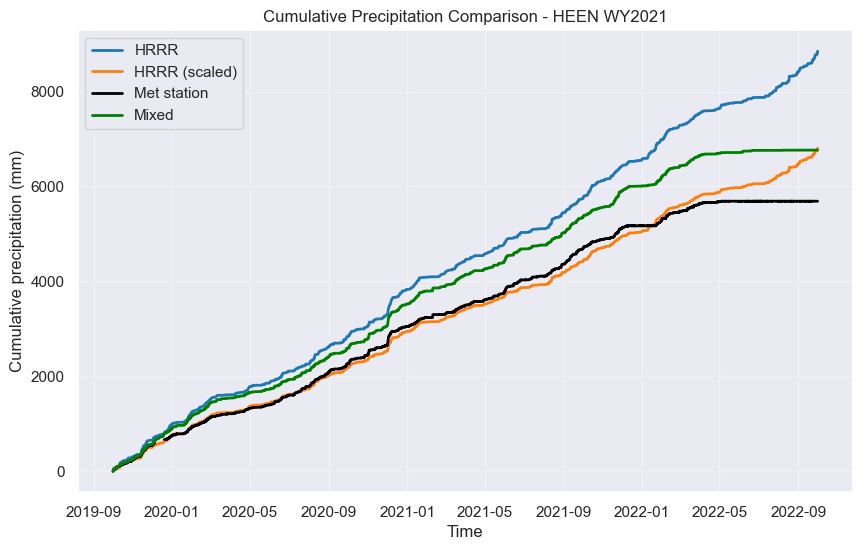

In [22]:
# =========================
# PRECIP COMPARISON PLOT
# =========================
plt.figure(figsize=(10,6))

# HRRR precip
hrrr_psum = pd.Series(ds_psum.values, index=time_index)
plt.plot(hrrr_psum.cumsum(), label="HRRR", linewidth = 2, color='tab:blue')

# HRRR precip scaled by 1.3
hrrr_psum = pd.Series(ds_psum.values, index=time_index)
hrrr_psum_scaled = hrrr_psum / 1.3
plt.plot(hrrr_psum_scaled.cumsum(), label="HRRR (scaled)", linewidth = 2, color='tab:orange')

# Met station precip
met_psum = ds_met_aligned['precip_accum_1hr'].to_series()
plt.plot(met_psum.cumsum(), label="Met station", linewidth = 2, color='black')

# Mixed precip
mix_psum = ds_filled['PSUM'].to_series()
plt.plot(mix_psum.cumsum(), label="Mixed", linewidth = 2, color='green')

plt.ylabel("Cumulative precipitation (mm)")
plt.xlabel("Time")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Cumulative Precipitation Comparison - HEEN WY2021")
plt.show()

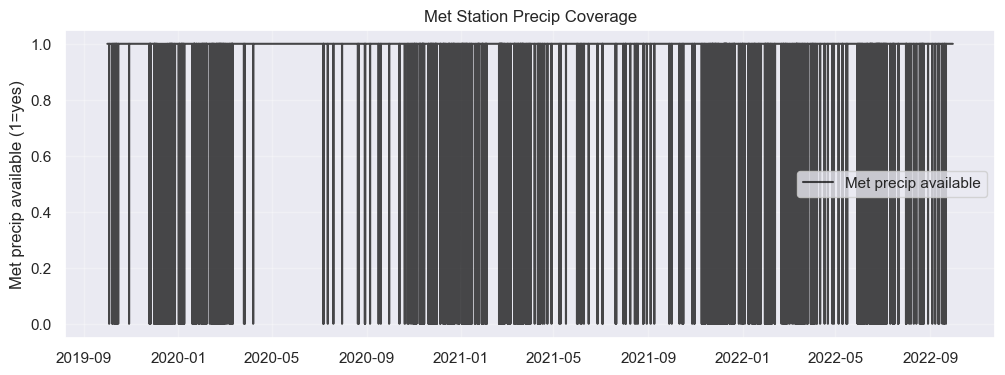

In [52]:
# Quick coverage plot
plt.figure(figsize=(12,4))
coverage = (~ds_met_aligned['precip_accum_1hr'].isnull()).to_series()
plt.plot(coverage, label='Met precip available', color='black', alpha=0.7)
plt.ylabel('Met precip available (1=yes)')
plt.title('Met Station Precip Coverage')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [53]:
print("Time overlap check:")
print(f"Met times: {len(ds_met.time)}")
print(f"HRRR times: {len(ds_hrrrak.time)}")
# print(f"Common times: {len(ds_met.time.intersection(ds_hrrrak.time))}")

Time overlap check:
Met times: 26281
HRRR times: 26281


In [54]:
# =========================
# DEBUG: Precip Coverage Check
# =========================
print("\n=== PRECIP COVERAGE DEBUG ===")
print(f"Met station precip coverage: {float(ds_met_aligned['precip_accum_1hr'].notnull().mean()):.1%}")
print(f"Number of timesteps with met precip: {int(ds_met_aligned['precip_accum_1hr'].notnull().sum())}")
print(f"Total timesteps: {len(time_index)}")

# Show where met data is missing
missing_mask = ds_met_aligned['precip_accum_1hr'].isnull()
print(f"First 10 missing met precip timesteps:")
print(pd.to_datetime(ds_hrrrak.time.values)[missing_mask][0:10])


=== PRECIP COVERAGE DEBUG ===
Met station precip coverage: 89.3%
Number of timesteps with met precip: 23482
Total timesteps: 26281
First 10 missing met precip timesteps:
DatetimeIndex(['2019-10-03 11:00:00', '2019-10-03 13:00:00',
               '2019-10-07 09:00:00', '2019-10-07 10:00:00',
               '2019-10-07 11:00:00', '2019-10-07 12:00:00',
               '2019-10-08 19:00:00', '2019-10-10 18:00:00',
               '2019-10-10 19:00:00', '2019-10-11 08:00:00'],
              dtype='datetime64[ns]', freq=None)


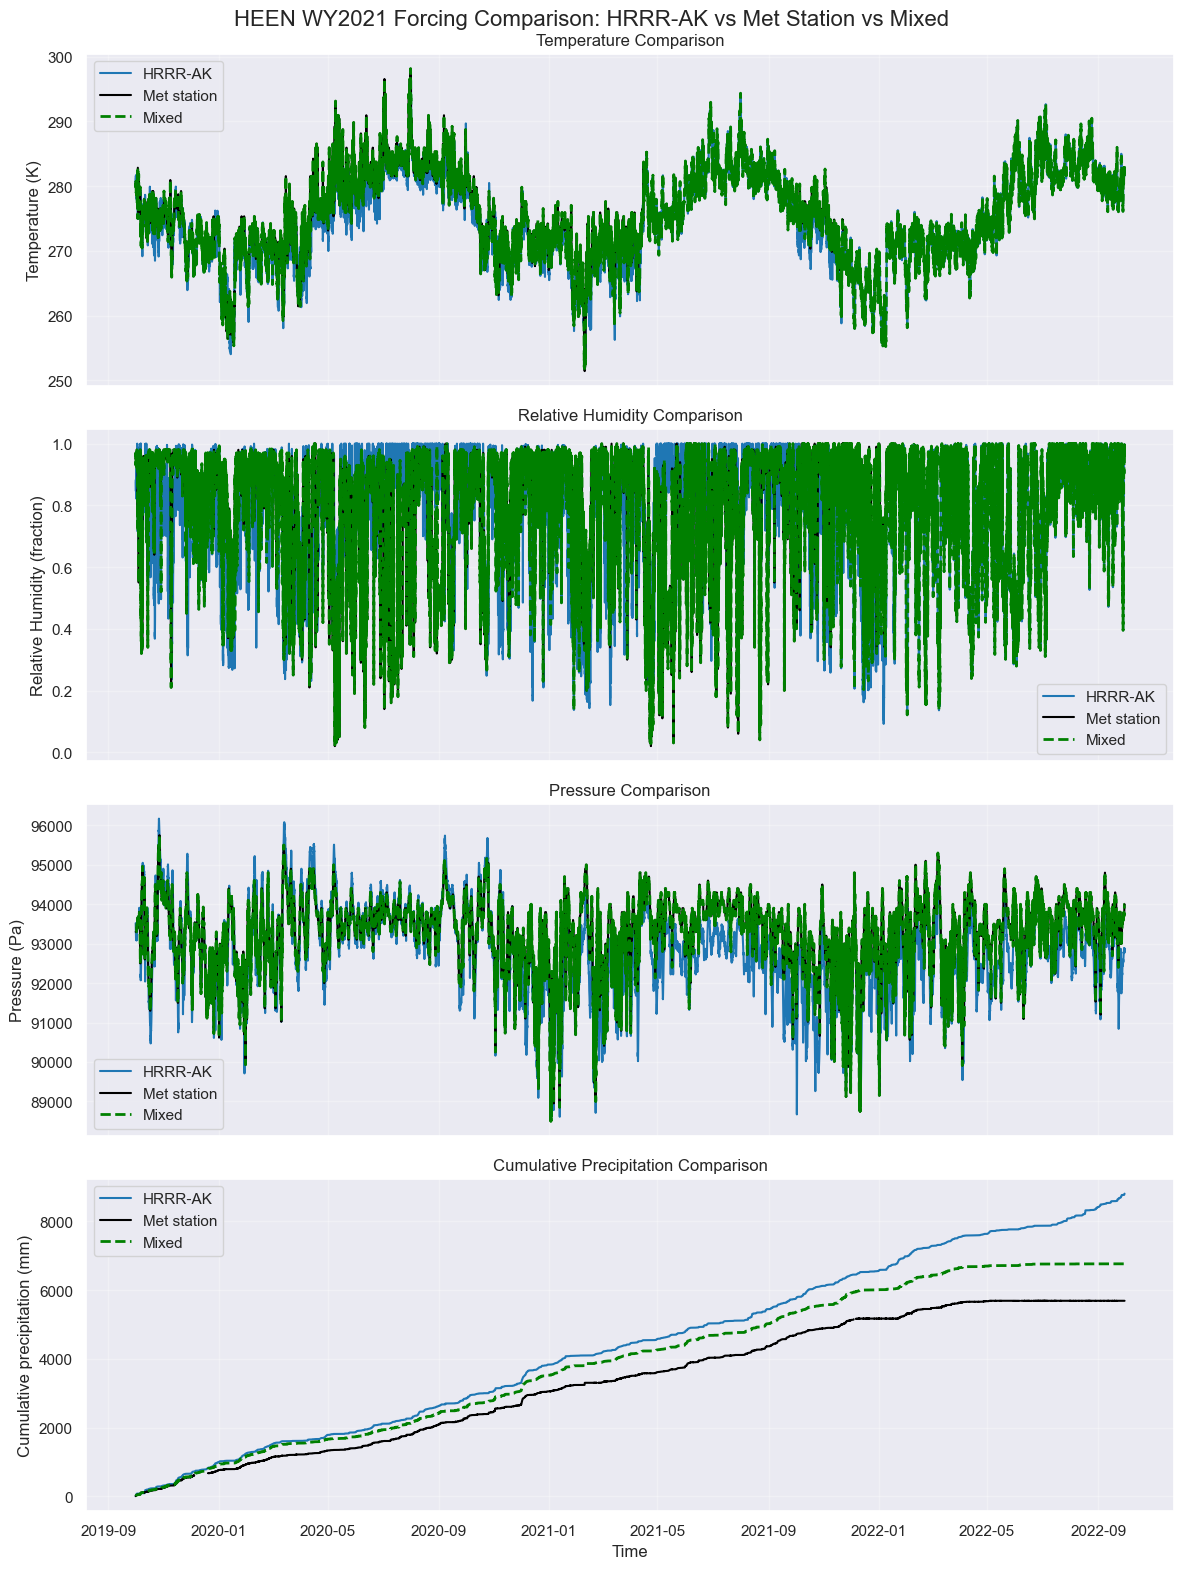

In [55]:
# =========================
# MULTI-VARIABLE COMPARISON PLOT
# =========================
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

# -------------------------
# Temperature (TA)
# -------------------------
ax = axes[0]

# HRRR temperature (K)
hrrr_ta = pd.Series(ds_temp_k.values, index=time_index)

# Met temperature (K)
met_ta = ds_met_aligned['temp'].to_series()

# Mixed temperature (K)
mix_ta = ds_filled['TA'].to_series()

ax.plot(hrrr_ta, label="HRRR-AK", color='tab:blue')
ax.plot(met_ta, label="Met station", color='black')
ax.plot(mix_ta, label="Mixed", color='green', linestyle='--', linewidth=2)

ax.set_ylabel("Temperature (K)")
ax.set_title("Temperature Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Relative Humidity (RH)
# -------------------------
ax = axes[1]

# HRRR RH (fraction)
hrrr_rh = pd.Series(ds_rh_frac.values, index=time_index)

# Met RH (fraction, already converted)
met_rh = ds_met_aligned['rh'].to_series()

# Mixed RH (fraction)
mix_rh = ds_filled['RH'].to_series()

ax.plot(hrrr_rh, label="HRRR-AK", color='tab:blue')
ax.plot(met_rh, label="Met station", color='black')
ax.plot(mix_rh, label="Mixed", color='green', linestyle='--', linewidth=2)

ax.set_ylabel("Relative Humidity (fraction)")
ax.set_title("Relative Humidity Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Pressure (PS)
# -------------------------
ax = axes[2]

# HRRR pressure (Pa)
hrrr_ps = pd.Series(ds_hrrrak['pressure'].values, index=time_index)

# Met pressure (Pa, prefer met)
met_ps = ds_met_aligned['pressure'].fillna(ds_hrrrak['pressure']).to_series()

# Mixed pressure (Pa)
mix_ps = df_smet['PS']  # From final df_smet

ax.plot(hrrr_ps, label="HRRR-AK", color='tab:blue')
ax.plot(met_ps, label="Met station", color='black')
ax.plot(mix_ps, label="Mixed", color='green', linestyle='--', linewidth=2)

ax.set_ylabel("Pressure (Pa)")
ax.set_title("Pressure Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Precipitation (cumulative)
# -------------------------
ax = axes[3]

# HRRR precip
hrrr_psum = pd.Series(ds_psum.values, index=time_index)

# Met precip
met_psum = ds_met_aligned['precip_accum_1hr'].to_series()

# Mixed precip
mix_psum = ds_filled['PSUM'].to_series()

ax.plot(hrrr_psum.cumsum(), label="HRRR-AK", color='tab:blue')
ax.plot(met_psum.cumsum(), label="Met station", color='black')
ax.plot(mix_psum.cumsum(), label="Mixed", color='green', linestyle='--', linewidth=2)

ax.set_ylabel("Cumulative precipitation (mm)")
ax.set_title("Cumulative Precipitation Comparison")
ax.grid(alpha=0.3)
ax.legend()

# -------------------------
# Common x-axis
# -------------------------
axes[-1].set_xlabel("Time")
plt.suptitle("HEEN WY2021 Forcing Comparison: HRRR-AK vs Met Station vs Mixed", fontsize=16)
plt.tight_layout()
plt.show()